# Code Assignment Mod6L14 — Confusion Matrix & Metrics on Restaurant Inspections

**Format:** Instructor Guidance → Your Task → We Share (Reflection)

**Goal:** Using the same **classification workflow** and models as last time, build confusion matrices and calculate accuracy, precision, and recall of each model.  


## Instructor Guidance (Pseudocode + Docs)

Use this as a roadmap; students implement below.

**Docs (quick links):**
- Train/Test Split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- Logistic Regression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html  
- Confusion Matrix / Classification Report — scikit-learn: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics  
- `pandas.get_dummies` (one-hot) — https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html

### Guidance (same models as last challenge -- FEEL free to copy and paste the code that you need from the last code assignment)

1) **Load CSV** → preview shape & columns.  
2) **Define target (y)** as a **binary** label: e.g., `CRITICAL FLAG == "Critical"` → 1, else 0 *(positive class = “Critical”)*.  
3) **Pick features (X)**: start small (`SCORE`), then add categorical dummies (`BORO`, `CUISINE DESCRIPTION`), keep it simple.  
4) **Minimal prep**: coerce **only used columns** to numeric (for numeric features); `get_dummies` for categoricals (`drop_first=True`). Drop NA rows on used cols.  
5) **Train–test split (80/20)** with fixed `random_state`.  
6) **Fit the same model** as last time (e.g., `LogisticRegression`), predict on **test**.  
7) **Evaluate**: confusion matrix, **accuracy**, **precision**, **recall**, **F1** (classification_report).  
8) **Repeat for 2 more models** (A (baseline)/B (single term)/C (more than one term)) on the **same split**; compare metrics.  
9) **Decide** which model is better for the business goal based on **precision vs recall** trade-offs.  


## Your Task

Work in pairs. Comment your choices briefly. Keep code simple and readable.

> **Reminder (last challenge model):** You trained **LogisticRegression**, on three models you will use those same 3 models!


### 1) Read the Restaurant Inspection CSV & Preview

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("/Users/Marcy_Student/Downloads/DOHMH_New_York_City_Restaurant_Inspection_Results_20251104 copy.csv")
display(df.shape)

(291278, 27)

### 2) Define the Binary Target (y)

We’ll predict whether an inspection had a **Critical violation**.

- Target rule: `CRITICAL FLAG == "Critical"` → **1**, else **0**.
- Positive class = **1 (Critical)** — keep this in mind for **precision/recall** meaning.


In [25]:
df['CRITICAL_NUM'] = (df['CRITICAL FLAG'] == "Critical").astype(int)



### 3) Create Three Models (you can copy and paste the same modeling code from last code assignment here it is okay if your models have different features as long as you have 3 models)

- **Model A (minimal numeric):** `SCORE` only (lower is better in NYC scoring).  
- **Model B (add location):** `SCORE` + one-hot `BORO`.  
- **Model C (richer categories):** `SCORE` + one-hot `BORO` + top cuisines (one-hot of `CUISINE DESCRIPTION` limited to most frequent K).

> If any column is missing in your file, skip that spec or adjust accordingly.


In [ ]:
# Model A
X_A = df[['SCORE']]
y_A = df['CRITICAL_NUM']

# Model B
X_B = df[['SCORE', 'BORO']]
y_B = df['CRITICAL_NUM']


# Model C
top_cuisines = df['CUISINE DESCRIPTION'].value_counts().nlargest(5).index
df['CUISINE_TOP'] = df['CUISINE DESCRIPTION'].where(
    df['CUISINE DESCRIPTION'].isin(top_cuisines),
    'Other'
)

X_C = df[['SCORE', 'BORO', 'CUISINE_TOP']]
y_C = df['CRITICAL_NUM']


### 4) Minimal Cleaning: Drop NAs in Used Columns

Do this **per model** so each spec uses its own “clean” subset (same **target** slice).


In [40]:
modelA = pd.concat([X_A, y_A], axis=1)

# Converting SCORE to numeric
modelA['SCORE'] = pd.to_numeric(modelA['SCORE'], errors='coerce')

modelA_clean = modelA.dropna(subset=['SCORE', 'CRITICAL_NUM'])

X_A_clean = modelA_clean[['SCORE']]
y_A_clean = modelA_clean['CRITICAL_NUM']



modelB = pd.concat([X_B, y_B], axis=1)

modelB['SCORE'] = pd.to_numeric(modelB['SCORE'], errors='coerce')

# Droping NA's for columns
modelB_clean = modelB.dropna(subset=['SCORE', 'BORO', 'CRITICAL_NUM'])

# encode
X_B_clean = pd.get_dummies(modelB_clean[['SCORE', 'BORO']], drop_first=True)
y_B_clean = modelB_clean['CRITICAL_NUM']



modelC = pd.concat([X_C, y_C], axis=1)

modelC['SCORE'] = pd.to_numeric(modelC['SCORE'], errors='coerce')

modelC_clean = modelC.dropna(subset=['SCORE', 'BORO', 'CUISINE_TOP', 'CRITICAL_NUM'])

X_C_clean = pd.get_dummies(modelC_clean[['SCORE', 'BORO', 'CUISINE_TOP']], drop_first=True)
y_C_clean = modelC_clean['CRITICAL_NUM']

### 5) Train–Test Split (same split for all models)

Use **the same random_state** so models A/B/C are comparable.


In [41]:
# Model A split
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A_clean, y_A_clean,test_size=0.2, random_state=42, stratify=y_A_clean)

# Model B split
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B_clean, y_B_clean,test_size=0.2, random_state=42, stratify=y_B_clean)

# Model C split
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(X_C_clean, y_C_clean,test_size=0.2, random_state=42, stratify=y_C_clean)


### 6) Fit the Same Models on the Train sets (Logistic Regression), Get Predictions, Print Confusion Matrices & Metric Reports

> **This is new**:  Be sure to look up documentation on `confusion_matrix` and `classification_report`.  Get a matrix and metrics report (accuracy, precision, recall, f1) for each model.


In [45]:
# Model A — SCORE only

modelA = LogisticRegression(max_iter=1000)
modelA.fit(X_train_A, y_train_A)

preds_A = modelA.predict(X_test_A)

cmA = confusion_matrix(y_test_A, preds_A)
print("Model A confusion Matrix:")
print(cmA)
print("\nClassification Report:")
print(classification_report(y_test_A, preds_A, digits=4))

# Model B — SCORE + BORO

modelB = LogisticRegression(max_iter=1000)
modelB.fit(X_train_B, y_train_B)

preds_B = modelB.predict(X_test_B)

cmB = confusion_matrix(y_test_B, preds_B)
print("Model B confusion Matrix:")
print(cmB)
print("\nClassification Report:")
print(classification_report(y_test_B, preds_B, digits=4))

# Model C — SCORE + BORO + Top Cuisines

modelC = LogisticRegression(max_iter=1000)
modelC.fit(X_train_C, y_train_C)

preds_C = modelC.predict(X_test_C)

cmC = confusion_matrix(y_test_C, preds_C)
print("Model C confusion Matrix:")
print(cmC)
print("\nClassification Report:")
print(classification_report(y_test_C, preds_C, digits=4))


Model A confusion Matrix:
[[ 5927 18264]
 [ 4085 26712]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5920    0.2450    0.3466     24191
           1     0.5939    0.8674    0.7051     30797

    accuracy                         0.5936     54988
   macro avg     0.5930    0.5562    0.5258     54988
weighted avg     0.5931    0.5936    0.5473     54988

Model B confusion Matrix:
[[ 5920 18271]
 [ 4073 26724]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5924    0.2447    0.3464     24191
           1     0.5939    0.8677    0.7052     30797

    accuracy                         0.5937     54988
   macro avg     0.5932    0.5562    0.5258     54988
weighted avg     0.5933    0.5937    0.5473     54988

Model C confusion Matrix:
[[ 6721 17470]
 [ 4712 26085]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5879    0.2778    0.3773     

### 7) Visualize One Confusion Matrix 

Be able to interpret this Matrix 

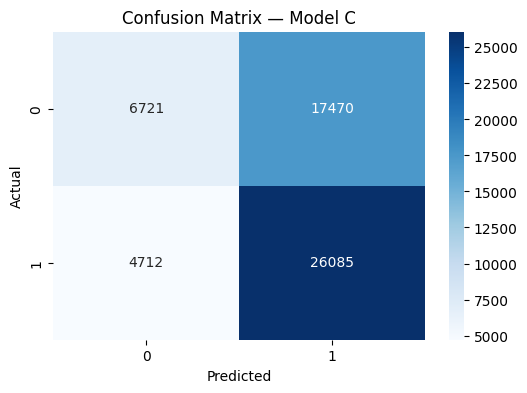

In [44]:
plt.figure(figsize=(6,4))
sns.heatmap(cmC, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Model C")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



### 8) Decide Which Model Is “Better” — Explain Your Metric Choice

- If the **cost of missing a Critical** violation is high → prioritize **Recall** on the positive class.  
- If the **cost of wrongly flagging Critical** is high → prioritize **Precision** on the positive class.  
- If you want a balance → **F1**.

Write 3–5 sentences justifying your pick using the table above (Precision/Recall/F1).


Across the three models, Model C performs the best overall. Even though all models have very similar precision and recall for identifying critical violations, Model C has the highest overall accuracy with (0.5966) and the best F1 scores, especially the weighted F1 (0.5590). Most importantly, because we're trying to catch critical violations, recall matters most. Model C still maintains a strong recall of about 85%, meaning it catches most inspections that truly are critical, while doing a slightly better job balancing mistakes on the non-critical classification. So even though the improvements are small, Model C provides the best combination of accuracy, recall, and F1, making it the strongest model for identifying critical violations.

## We Share (Reflection)

1) **Chosen model (A/B/C)** and **why**, referencing **Precision/Recall/F1** for the **Critical (1)** class.  
2) Your **confusion matrix** and a one-liner in plain English:  
   - “Out of all inspections we predicted **Critical**, **X%** were actually Critical (Precision).  
   - Of all actually **Critical** inspections, we caught **Y%** (Recall).”  

I chose Model C as the best model because it performs slightly better than the other two across most evaluation metrics. Model C has the highest overall accuracy of 0.5966 and the strongest F1 scores, meaning it balances correct predictions for both critical and non-critical inspections better than the simpler models. It also maintains a high recall for critical inspections wwith about 85%, which is important since missing a critical violation is a bigger problem than flagging one by mistake. 

In plain english when the model predicts a critical violation, about 60% of those predictions are actually critical (aka precision), and it successfully catches about 85% of all real critical violations (aka recall). Even though all models are close in performance, Model C gives the most reliable results for identifying high-risk restaurants.